In [1]:
import gymnasium as gym
import tools
import numpy as np
import logging

from tools.planners import MCGSPlanner
from tools.utils.plot_graph import plot_graph_2d, plot_spacetime_graph_3d, plot_graph_2d_live


In [2]:
# only from mcgs.py
logging.basicConfig(level=logging.WARNING, format='%(asctime)s - %(levelname)s - %(message)s')


In [3]:
gym.register(
    id="gymnasium_env/FrozenLakeContinuous-v0",
    entry_point="tools.envs.frozen_lake_continuous_wrapper:FrozenLakeSingleRobotEnv",
)
# gym.pprint_registry()

In [4]:
env = gym.make("gymnasium_env/FrozenLakeContinuous-v0", 
               render_mode="human",
               size=20,
               n_puddles=0,
               n_obstacles=0,
               dt=1.0,
               max_velocity=1.0,
               slippery_everywhere=0.0,
               atol=0.0,
               rtol=0.2)
print("RESET:")
for i in range(2):
    print("--------------------- iteration", i)
    obs, info = env.reset(seed=123)
    print(obs, info)
    print(env.np_random.uniform(0,1,1))
    env.reset()


/home/christoph/Dokumente/research/projects/dec-mcgs/.venv/lib/python3.12/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/christoph/Dokumente/research/projects/dec-mcgs/.venv/lib/python3.12/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Starting initialization of SingleIntegrator
Finished initialization of SingleIntegrator
RESET:
--------------------- iteration 0
start_obs: [1.0764204  4.4071975  0.59697247 3.687436   3.518118  ] goal_obs: [3.687436 3.518118      nan 3.687436 3.518118]
[1.0764204  4.4071975  0.59697247 3.687436   3.518118  ] {'Sampled states': [array([1.0764204 , 4.4071975 , 0.59697247], dtype=float32), array([3.687436, 3.518118,      nan], dtype=float32)]}
[0.68235186]
start_obs: [ 8.6481285 19.600595   1.4066558  0.8205318 14.301482 ] goal_obs: [ 0.8205318 14.301482         nan  0.8205318 14.301482 ]
--------------------- iteration 1
start_obs: [1.0764204  4.4071975  0.59697247 3.687436   3.518118  ] goal_obs: [3.687436 3.518118      nan 3.687436 3.518118]
[1.0764204  4.4071975  0.59697247 3.687436   3.518118  ] {'Sampled states': [array([1.0764204 , 4.4071975 , 0.59697247], dtype=float32), array([3.687436, 3.518118,      nan], dtype=float32)]}
[0.68235186]
start_obs: [ 9.890652   17.604437    0.466

In [5]:
env.reset(seed=10)

start_obs: [ 4.153636   16.568897    0.77432096  2.9856424  10.256092  ] goal_obs: [ 2.9856424 10.256092         nan  2.9856424 10.256092 ]


(array([ 4.153636  , 16.568897  ,  0.77432096,  2.9856424 , 10.256092  ],
       dtype=float32),
 {'Sampled states': [array([ 4.153636  , 16.568897  ,  0.77432096], dtype=float32),
   array([ 2.9856424, 10.256092 ,        nan], dtype=float32)]})

In [6]:
planner = MCGSPlanner(robot=env.unwrapped.robot,
                      reward_function=env.unwrapped.reward_function,
                      max_iterations=500, 
                      expand_n_times=1,
                      kappa=1.6, # 1.6
                      alpha=0.3, # 0.3
                      k=8,
                      radius_threshold=0.0,#1.0, # 1.8,
                      abstraction_refinement_exponent=-0.1,
                      c_uct=0.4,
                      plan_in_space_time=True)

env.unwrapped.connect_planner(planner)

In [7]:
# from gymnasium.utils.env_checker import check_env

# # This will catch many common issues
# try:
#     check_env(env.unwrapped)
#     print("Environment passes all checks!")
# except Exception as e:
#     print(f"Environment has issues: {e}")

In [8]:
planner.agent

Robot(id=0, name=agent, state=[ 4.153636   16.568897    0.77432096])

Plan: [0, 3, 13, 16, 36, 40, 50, 56, 60, 71, 79, 93, 99]
State: [ 1.9427917 11.198836  12.774321 ]
Plan actions: [array([ 0.02560923, -0.7281608 ], dtype=float32), array([ 0.03566843, -0.3550509 ], dtype=float32), array([-0.69114983, -0.50044894], dtype=float32), array([-0.61424565, -0.33356622], dtype=float32), array([ 0.01725872, -0.35079142], dtype=float32), array([-0.9739251, -0.9602499], dtype=float32), array([-0.12690192, -0.90050983], dtype=float32), array([-0.43151867, -0.08720957], dtype=float32), array([ 0.03261014, -0.439623  ], dtype=float32), array([ 0.81377715, -0.7697687 ], dtype=float32), array([-0.37043878,  0.33838567], dtype=float32), array([ 0.07241228, -0.28306717], dtype=float32)]
Finished?  False


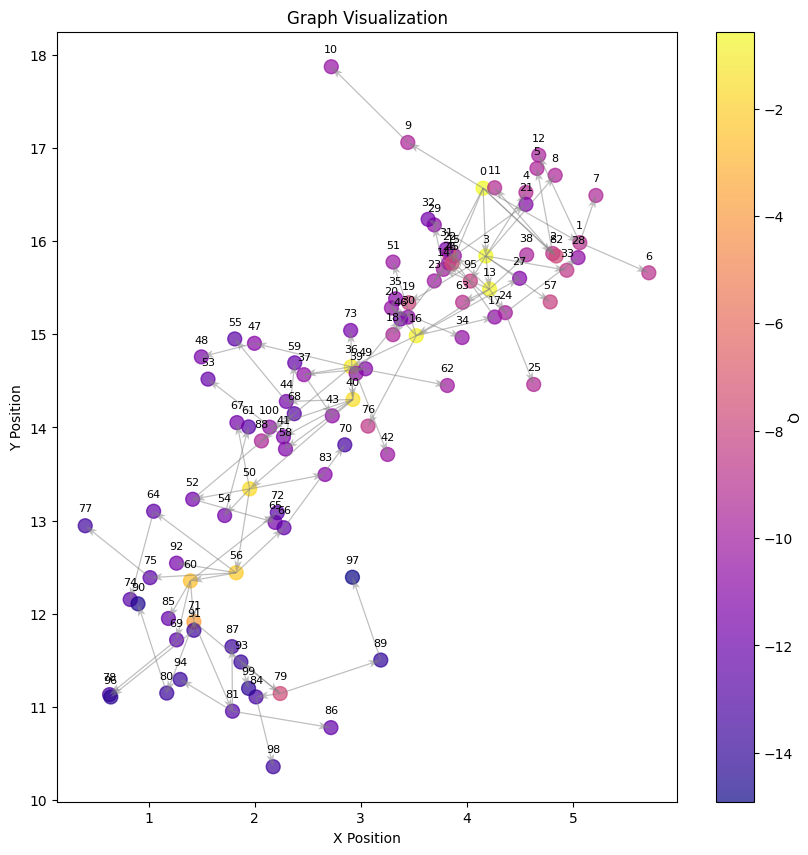

In [9]:
planner.reset_graph()
planner.plan(iterations=100, expand_n_times=1)
# 
plot_graph_2d(planner.graph, plot_labels=True, scatter_mode='Q', plot_values=False, bbox=None)


plan, plan_actions = planner.yield_plan()
state = env.unwrapped.planner.graph[plan[-1]].state
print("Plan:", plan)
print("State:", state)
print("Plan actions:", plan_actions)
print("Finished? ", env.unwrapped.robot.is_finished(state=state))

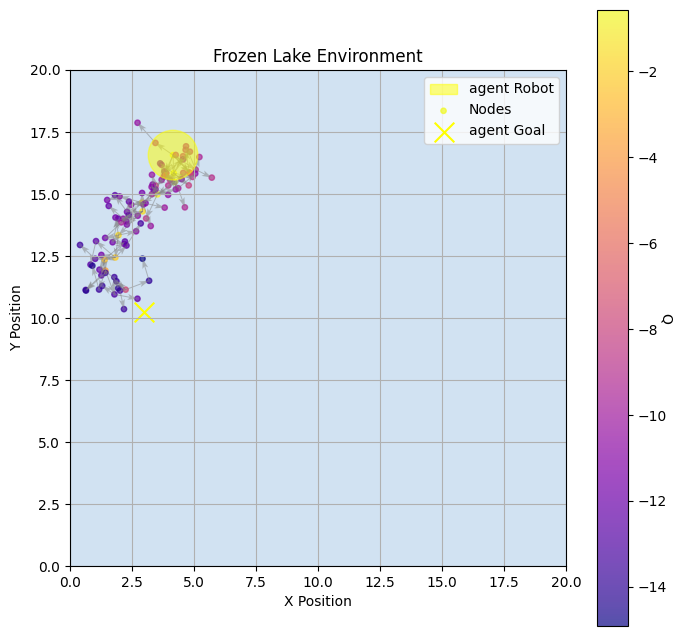

In [10]:
fig = env.render()

In [11]:
episode_over = False
total_reward = 0

planner.reset_graph()
planner.plan(iterations=50) # Bootstrapping

i = 0
while not episode_over:

    planner.plan(iterations=50, expand_n_times=1)
    plan, plan_actions = planner.yield_plan(atol=env.unwrapped.atol, rtol=env.unwrapped.rtol, max_length=10)
    planner.update_trajectory_plan(plan)
    assert len(plan) > 0, "Plan does not include successor node"

    # Take the action and see what happens
    observation, reward, terminated, truncated, info = env.step(plan_actions[0])

    planner.update_planner()


    total_reward += reward
    episode_over = terminated or truncated
    i += 1
    env.render()
print(f"Episode finished! Total reward: {total_reward} after {i} iterations")
env.close()


TypeError: Robot.step() takes 2 positional arguments but 3 were given